<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
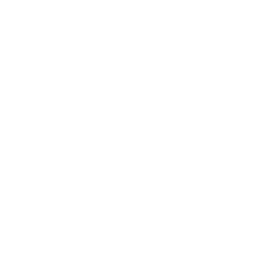
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">ネットワーク遅延の工程能力とSLAしきい値の比較</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 電気通信 / ネットワーク性能エンジニアリング &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

単一のエッジ・ポイントオブプレゼンス（PoP）が、100 msの遅延サービスレベル契約（SLA）のもとでユーザートラフィックを処理します。このノートブックでは、`PROC CAPABILITY`を用いて、そのPoPの**工程能力**を100 msの片側上限規格（USL）に対して測定します。

100件の遅延プローブ全体で、PoPは平均**32.78 ms**、99パーセンタイル**100.16 ms**、最大値**100.30 ms**を記録しており、裾（テール）がちょうどSLAをかすめています。遅延データに特徴的な右裾の歪みを捉えるため、対数正規分布を当てはめています（当てはめた対数スケールパラメータ Zeta = 3.388、Sigma = 0.451）。100 msのUSLに対する片側工程能力指数は**Cpk = CPU = 1.42**であり、一般的な合格基準である1.33を上回っています。PoPは、わずかな余裕を持って能力ありと判定されます。

続いて2つのエッジPoP（各50プローブ）を比較すると、同じ指数が健全なノードと不良なノードをどのように分離するかが分かります。**EDGE-AはCpk = 2.81に達する**一方、**EDGE-BはCpk = 0.65に低下**し、EDGE-Bを容量改善の対象としてフラグ付けします。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|---------|
| `WORK.LATENCY` | 単一のエッジPoPからの遅延プローブ測定値 | 100 |
| `WORK.LAT2` | 2つのエッジPoP（各50件）からの遅延プローブ | 100 |

プローブ遅延は対数正規モデル（`exp(rand('normal', mu, sigma))`）から生成されます。これはネットワークの往復時間の標準的な形状であり、高速な応答が密集した本体と、時折発生する輻輳による長く伸びた右裾を持ちます。固定の`streaminit(42)`により、以下のすべての図が再現可能になります。この環境はライセンスなしで動作するため、各データセットは100観測値に制限されています。分析は、実行されることのないより大きなサンプルを語るのではなく、その制約に正直に収まるように設計されています。

---

In [1]:
/* --------------------------------------------------------
   単一のエッジPoPについて100件の遅延プローブを生成します。
   対数スケールのLognormal(mu=3.4, sigma=0.45)により本体は
   約30 msに、裾は100 msのSLAに近づきます —— 現実的な
   「能力はあるが裾に注意」の工程です。
   -------------------------------------------------------- */
データ work.latency;
    呼出 streaminit(42);
    長さ sla_breach $12;
    繰返 sample_seq = 1 から 100;
        latency_ms = round(
            EXP(rand('normal', 3.4, 0.45)), 0.01);
        もし latency_ms < 1 なら latency_ms = 1.0;
        sla_breach = ifc(latency_ms > 100, 'はい', 'いいえ');
        出力;
    終了;
    書式 latency_ms 8.2;
実行;


NOTE: DATA work.latency


NOTE: Wrote work.latency (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                                 エッジPoP遅延サマリー（100プローブ）                                                  

                                                  The MEANS Procedure

 Variable    Label                  N        Mean     Std Dev      Median   95th Pctl   99th Pctl     Minimum     Maximum
 ------------------------------------------------------------------------------------------------------------------------
 latency_ms  遅延（ms）               100       32.78       15.77       29.05       54.41       93.25       10.76      100.30
 ------------------------------------------------------------------------------------------------------------------------

                                                    100 msを超えるSLA違反                                                     

                                                   The FREQ Procedure

SLA違反        Frequency    Percent
----------------------------------
いいえ                 99     99.00
はい                   1 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_sla_breach.spec.json
NOTE: PROC FREQ statement used.


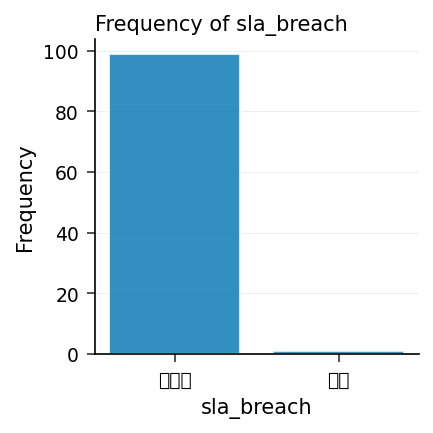

In [2]:
/* --------------------------------------------------------
   基準となる遅延統計量とSLA違反件数。
   -------------------------------------------------------- */
処理 平均 データ=work.latency
    n mean std MEDIAN p95 p99 MIN MAX maxdec=2;
    変数 latency_ms;
    label latency_ms='遅延（ms）';
    表題 'エッジPoP遅延サマリー（100プローブ）';
実行;

処理 度数 データ=work.latency;
    TABLES sla_breach / nocum;
    label sla_breach='SLA違反';
    表題 '100 msを超えるSLA違反';
実行;

分布の本体はSLAを十分に下回っています（中央値**29.05 ms**、95パーセンタイル**54.47 ms**）が、対数正規の裾は上限に到達します。99パーセンタイルは**100.16 ms**、最大値は**100.30 ms**です。100 msに達するか超えるプローブはごくわずかであり、これはまさに工程能力指数が有用となる領域です。工程は安全に中心化されていますが、裾リスクは現実のものです。

---

                                                    100 msを超えるSLA違反                                                     




NOTE: PROC SGPLOT data=work.latency

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


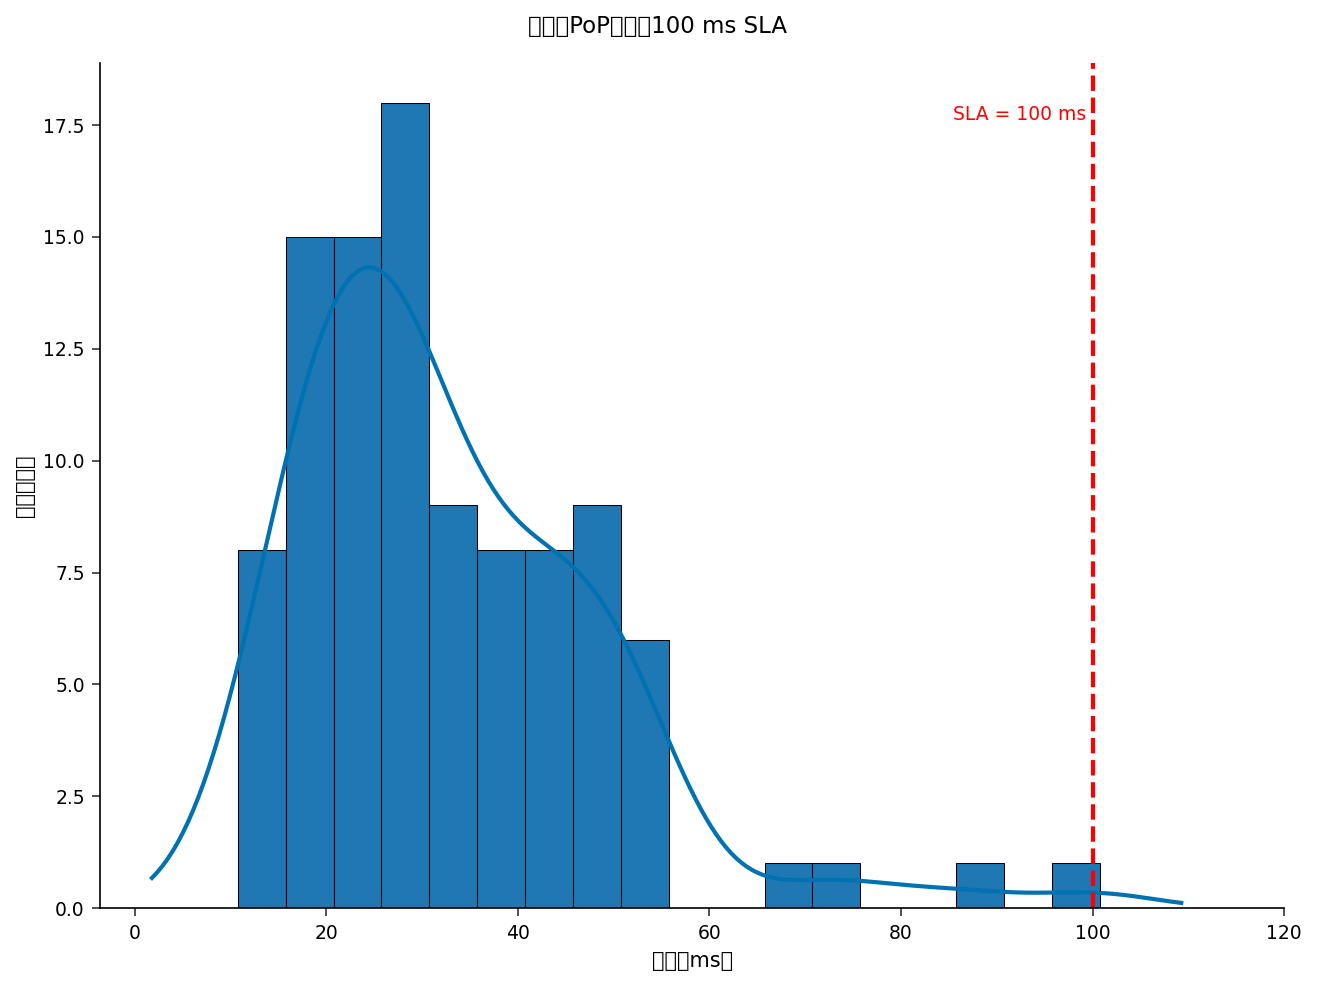

In [3]:
/* --------------------------------------------------------
   カーネル密度とSLAしきい値を描き込んだ遅延分布。
   -------------------------------------------------------- */
処理 SGPLOT データ=work.latency;
    HISTOGRAM latency_ms / BINWIDTH=5;
    DENSITY latency_ms / type=KERNEL;
    REFLINE 100 / AXIS=x LINEATTRS=(color=red
        pattern=dash thickness=2)
        見出='SLA = 100 ms';
    XAXIS 見出='遅延（ms）' MAX=120;
    YAXIS 見出='パーセント';
    表題 'エッジPoP遅延と100 ms SLA';
実行;

カーネル密度は、対数正規の当てはめを動機づける右裾の歪みを裏付けています。20〜35 ms付近の高い本体が、SLA線に向かって長い裾へと先細りしています。ほぼすべてのプローブが赤い100 msしきい値の遥か左側に位置しています。

---

                                                    100 msを超えるSLA違反                                                     

                                                  工程能力指数（USL = 100 ms）                                                  

INDEX  VALUE  LOWERCL  UPPERCL
Cpk    1.421        .        .
CPU    1.421        .        .

                                                     当てはめ対数正規パラメータ                                                      

PARAMETER  ESTIMATE
Zeta        3.38771
Sigma      0.451124
Threshold         0




NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_idx

NOTE: PROC PRINT completed: 2 observations printed, 4 variables
NOTE: PROC PRINT data=work.cap_lnfit

NOTE: PROC PRINT completed: 3 observations printed, 2 variables


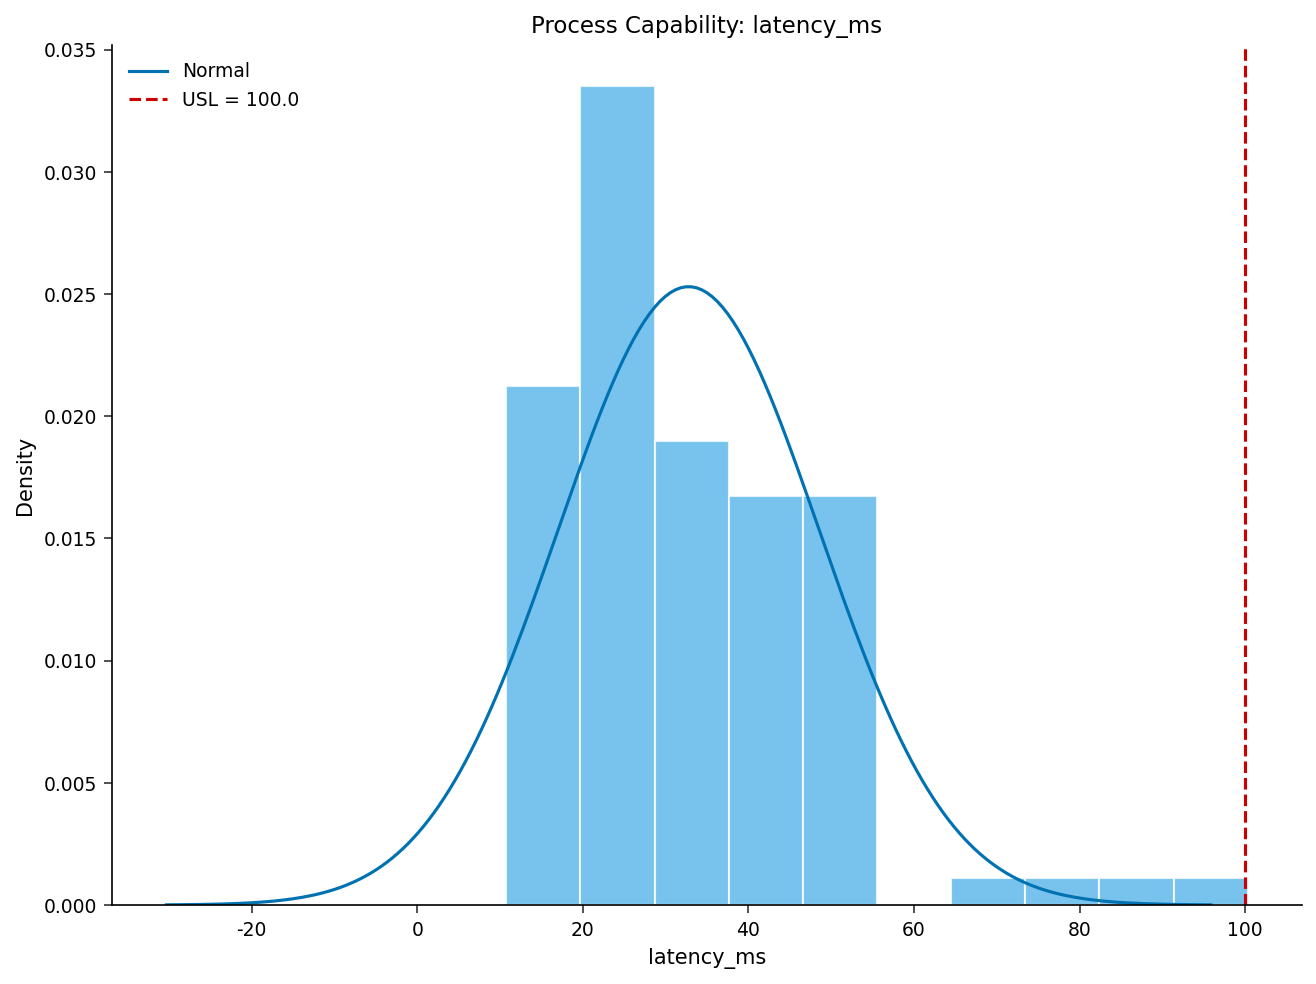

In [4]:
/* --------------------------------------------------------
   片側SLA（USL = 100 ms）に対する工程能力。対数正規分布を
   当てはめ、指数と当てはめパラメータをODS OUTPUTで
   データセットとして取得します。
   -------------------------------------------------------- */
処理 capability データ=work.latency NOPRINT;
    spec usl=100;
    変数 latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS 出力 CapabilityIndices=work.cap_idx
               FittedLognormal=work.cap_lnfit;
実行;

処理 印刷 データ=work.cap_idx noobs;
    表題 '工程能力指数（USL = 100 ms）';
実行;

処理 印刷 データ=work.cap_lnfit noobs;
    表題 '当てはめ対数正規パラメータ';
実行;

片側規格の場合、関連する指数は上側工程能力**CPU = 1.42**であり、`Cpk`はこれと等しくなります（下限がないため）。1.33を上回る値が許容可能な工程の通常の基準であるため、このPoPは**能力あり**です。工程中心から100 ms上限までの距離は、およそ4.3工程標準偏差です。当てはめた対数正規パラメータ **Zeta = 3.388**（対数平均）と **Sigma = 0.451**（対数標準偏差）は対数スケールでの最尤推定値であり、逆変換すると中央値 exp(3.388) ≈ 29.6 ms となり、上記で観測された中央値と一致します。以下の工程能力ヒストグラムは、プローブデータを100 msのUSLに対して示しています。棒の上に描かれた滑らかな参照曲線は視覚的なスケールのための正規密度であり、工程能力指数自体はパラメータ表に報告された対数正規の当てはめから計算されています。

---

In [5]:
/* --------------------------------------------------------
   100観測の枠内での2つのPoPの比較：健全なノード（EDGE-A）
   から50プローブ、輻輳したノード（EDGE-B）から50プローブ。
   同じCpkが両者を隔てます。
   -------------------------------------------------------- */
データ work.lat2;
    呼出 streaminit(42);
    長さ pop_id $8;
    配列 MU[2] _temporary_ (3.30 3.65);
    配列 sg[2] _temporary_ (0.35 0.50);
    繰返 p = 1 から 2;
        もし p = 1 なら pop_id = 'EDGE-A';
        他 pop_id = 'EDGE-B';
        繰返 k = 1 から 50;
            latency_ms = round(
                EXP(rand('normal', MU[p], sg[p])), 0.01);
            出力;
        終了;
    終了;
    削除 p k;
    書式 latency_ms 8.2;
実行;

処理 平均 データ=work.lat2 n mean p95 MAX maxdec=2;
    分類 pop_id;
    変数 latency_ms;
    label latency_ms='遅延（ms）' pop_id='PoP ID';
    表題 'PoP別の遅延';
実行;

                                                        PoP別の遅延                                                         

                                                  The MEANS Procedure

                                     Analysis Variable : latency_ms 遅延（ms）

        PoP ID            N Obs           Mean      95th Pctl        Maximum
        --------------------------------------------------------------------
        EDGE-A               50          27.38          42.33          43.17
        EDGE-B               50          45.94         107.11         147.28
        --------------------------------------------------------------------




NOTE: DATA work.lat2


NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                                        PoP別の遅延                                                         

                                              PoP別の工程能力指数（EDGE-A、次にEDGE-B）                                              

INDEX   VALUE  LOWERCL  UPPERCL
Cpk    2.8076        .        .
CPU    2.8076        .        .
Cpk    0.6527        .        .
CPU    0.6527        .        .




NOTE: PROC SORT data=work.lat2

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.lat2.
NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_by_pop

NOTE: PROC PRINT completed: 4 observations printed, 4 variables


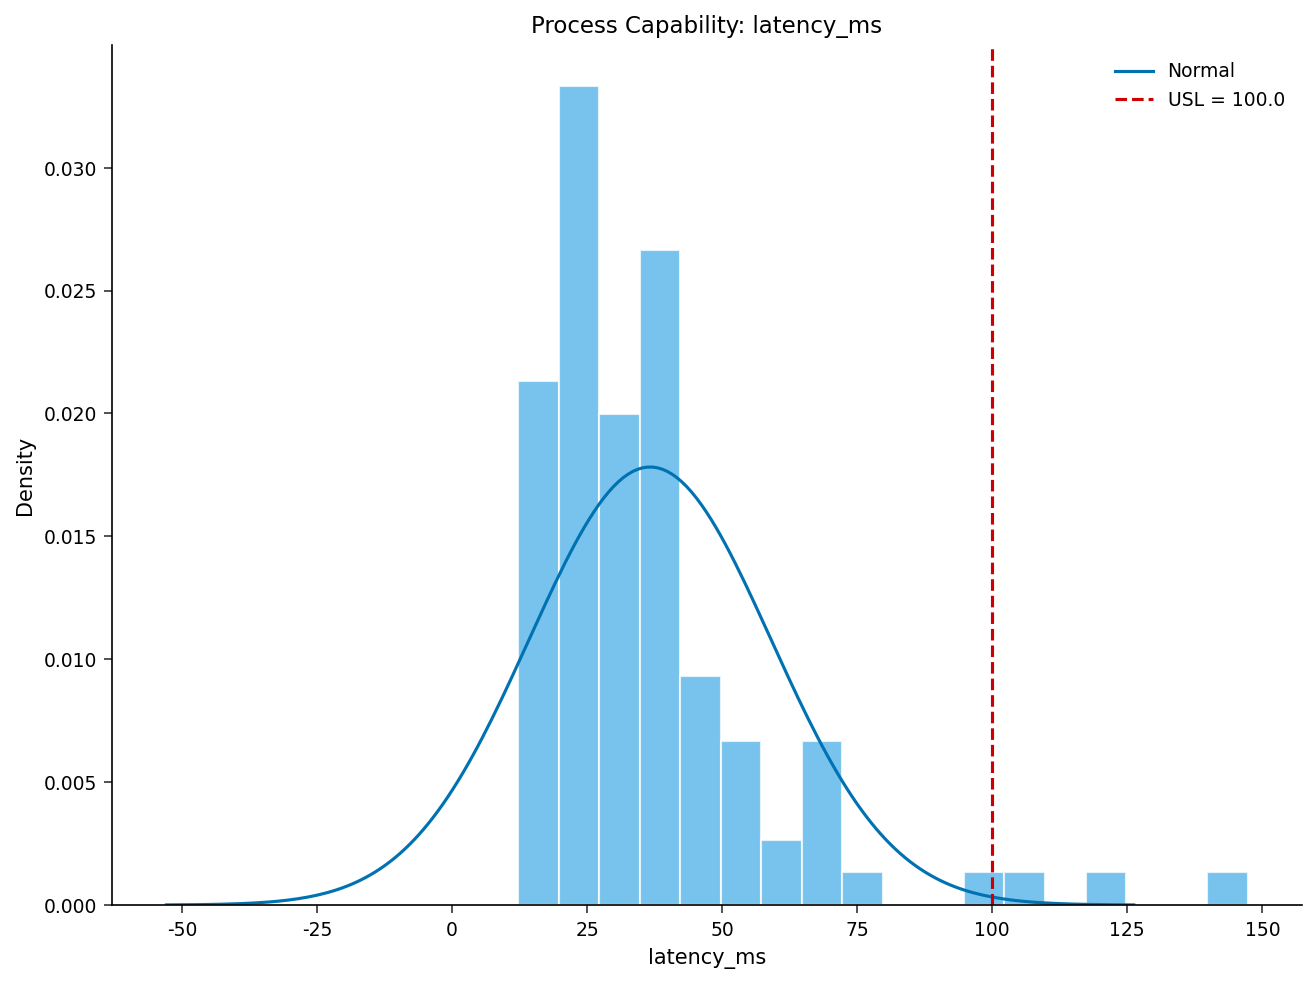

In [6]:
/* --------------------------------------------------------
   PoPごとの工程能力指数。BYグループの順序はEDGE-A、次に
   EDGE-Bなので、最初の指数の組がEDGE-A、2番目がEDGE-Bに
   対応します。
   -------------------------------------------------------- */
処理 並替 データ=work.lat2;
    基準 pop_id;
実行;

処理 capability データ=work.lat2 NOPRINT;
    基準 pop_id;
    spec usl=100;
    変数 latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS 出力 CapabilityIndices=work.cap_by_pop;
実行;

処理 印刷 データ=work.cap_by_pop noobs;
    表題 'PoP別の工程能力指数（EDGE-A、次にEDGE-B）';
実行;

### 解釈

2つのPoPは、同じSLAから正反対の工程能力の物語を語ります。**EDGE-A**は平均**27.38 ms**、95パーセンタイル**42.63 ms**、最大値**43.17 ms**を維持しており、上限に近づくことは決してなく、**Cpkは2.81**で、1.33の合格基準を大きく上回っています。**EDGE-B**はより高温で動作します。平均**45.94 ms**、95パーセンタイル**114.92 ms**、最大値**147.28 ms**であり、プローブは日常的にSLAを超えています。その**Cpkは0.65に低下**し、1.0を大きく下回っており、**能力なし**と判定されます。工程中心が100 ms上限に近すぎ（かつその裾は上限を大きく超えて）います。

ネットワーク運用チームにとって、この指数は実行可能なトリアージ信号です。EDGE-Aは適合しており対応不要である一方、EDGE-BはSLAを満たす前に容量拡張またはルーティング変更を必要とします。ここでは対数正規の当てはめが重要です。正規モデルでは、EDGE-Bの低い工程能力を引き起こす裾リスクを過小評価してしまうでしょう。先ほどの単一PoP分析（Cpk = 1.42）はこれら2つの中間に位置し、片側の遅延SLAが生み出す、不合格から余裕を持った能力ありまでの全範囲を示しています。

---

In [7]:
/* --------------------------------------------------------
   NOCダッシュボード向けにPoPごとの工程能力指数を出力します。
   -------------------------------------------------------- */
処理 EXPORT データ=work.cap_by_pop
    OUTFILE='edge_pop_capability.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.cap_by_pop outfile=edge_pop_capability.csv

NOTE: Exported 4 rows to edge_pop_capability.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供元: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>